In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
import torch
import numpy as np
import pandas as pd
import os
import random
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

import src.global_config as gcfg
import src.gnn.config as gnn_config
import src.stats.config as stat_cfg
import src.gnn.pipeline as pipeline
import src.gnn.analysis as eanalysis
import src.stats.analysis as stat_analysis

In [39]:
#IMPORTANTE: solo es necesario correr una sola vez la siguiente función por cada dataset,
#los datos ya calculados se guardan en la carpeta Output/
#cabe mencionar que aun no hay una flexibilidad con respecto al modo usado, ya sea con 'ones'
#o 'bibliometric' el resultado se sobreescribe como 'resultados_30_corridas_{nombre_dataset}.csv

In [40]:
def ejecutar_30_corridas():
    num_corridas = 30
    resultados = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Iniciando {num_corridas} corridas en: {device}")

    # cargamos las metricas que ya calculamos
    df_stage2 = pd.read_csv(os.path.join(gcfg.OUTPUT_DIR, f"metricas_{stat_cfg.LEVEL}.csv"))
    
    # Nombres de las features originales para el alineamiento del PCA
    nombres_features = [f[1] for f in gcfg.FEATURES]
    df_features = eanalysis.obtener_promedios_anuales(df_stage2['year'].values, nombres_features, gcfg.DATA_FOLDER)

    for i in range(num_corridas):
        print(f"\nProcesando Corrida {i+1}/{num_corridas} | Seed: {i} ---")
        
        # semillas
        random.seed(i)
        np.random.seed(i)
        torch.manual_seed(i)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(i)

        # Entrenar red neuronal
        historia, auc_mean = pipeline.run_temporal_graphsage(device)

        # Calcular PCA (1D) y Alinear
        df_flujo, metadatos_pca = eanalysis.calcular_pca_1d(historia)
        ev1_corrida = metadatos_pca["ev1"]
        w_corrida = metadatos_pca["loading"]

        # Diferencia entre embeddings  generados por medio del coseno
        if i == 0:
            # La primera corrida es nuestra referencia: el norte
            w_ref = w_corrida
            coseno_ref = 1.0 # Es idéntica a sí misma
        else:
            # Producto punto dividido por las magnitudes (fórmula del coseno)
            coseno_ref = np.dot(w_corrida, w_ref) / (np.linalg.norm(w_corrida) * np.linalg.norm(w_ref))
        
        df_flujo, _ = eanalysis.correlacionar_y_alinear(df_flujo, df_features, gnn_config.ALIGN_PC1_ANCHOR)
        df_flujo = df_flujo.rename(columns={"y_original": "sage_pc1"})

        # Unir datos y ajustar OLS
        df_all = pd.merge(df_stage2, df_flujo, on="year", how="inner")
        modelo_simple = stat_analysis.ajustar_modelo_ols(
            df_all, 
            y_col='sage_pc1', 
            x_cols=['mean_Percent of documents'], 
            usar_hac=True, 
            maxlags=3
        )

        # Pruebas de Hipótesis sobre los Residuos
        residuos = modelo_simple.resid
        
        # Normalidad
        _, shapiro_p = stats.shapiro(residuos)
        # Homocedasticidad (unicamente tomamos el valor del p value)
        _, bp_pvalue, _, _ = het_breuschpagan(residuos, modelo_simple.model.exog)
        # Independencia
        dw_stat = durbin_watson(residuos)

        print(f"  -> R2: {modelo_simple.rsquared:.4f} | Shapiro (p): {shapiro_p:.4f} | BP (p): {bp_pvalue:.4f} | DW: {dw_stat:.4f} | EV1: {ev1_corrida:.4f} | Coseno: {coseno_ref:.4f}")

        # Seleccion de features relevantes (del cual su coeficiente es distinto de cero)
        
        columnas_esperadas = [f"mean_{feat[1]}" for feat in gcfg.FEATURES] #unicamente agregamos  el prefijo mean_ 
        
        # un pequeño filtro, 
        todas_las_features = [col for col in columnas_esperadas if col in df_all.columns]
        features_candidatas = []
        
        
        # Filtramos por medio de regresion simple
        for feature in todas_las_features:
            mod_simple = stat_analysis.ajustar_modelo_ols(
                df_all, 'sage_pc1', [feature], usar_hac=True, maxlags=3
            )
            # Si el p-value de la feature es menor a 0.05, pasa a la final
            if mod_simple.pvalues[feature] < 0.05:
                features_candidatas.append(feature)

        # regresion multiple con los features relevantes
        if len(features_candidatas) > 0: # Solo armamos el modelo múltiple si al menos una feature pasó el filtro
            mod_multiple = stat_analysis.ajustar_modelo_ols(
                df_all, 'sage_pc1', features_candidatas, usar_hac=True, maxlags=3
            )
            
            # Ver quién sobrevivió al modelo múltiple (p < 0.05)
            sobrevivientes = []
            for feat in features_candidatas:
                if mod_multiple.pvalues[feat] < 0.05:
                    sobrevivientes.append(feat)
                    
            r2_final = mod_multiple.rsquared
            r2_adj_final = mod_multiple.rsquared_adj
            residuos = mod_multiple.resid
            
        else:
            # esto no deberia pasar pero por si acaso
            sobrevivientes = []
            r2_final = 0
            r2_adj_final = 0
            residuos = np.zeros(len(df_all)) # Residuos dummy para que no truene el código

        # algunas metricas sobre el modelo multiple
        _, shapiro_p = stats.shapiro(residuos) if len(features_candidatas) > 0 else (0, 0)
        
        if len(features_candidatas) > 0:
            _, bp_pvalue, _, _ = het_breuschpagan(residuos, mod_multiple.model.exog)
            dw_stat = durbin_watson(residuos)
        else:
            bp_pvalue, dw_stat = 0, 0

        # Imprimir progreso
        print(f"  -> R2 Múltiple: {r2_final:.4f} | Candidatas: {len(features_candidatas)} | Sobrevivientes: {len(sobrevivientes)}")

        # GUARDAR RESULTADOS
        resultados.append({
            "corrida": i + 1,
            "semilla": i,
            "r2_multiple": r2_final,
            "r2_adj_multiple": r2_adj_final,
            "num_candidatas": len(features_candidatas),
            "features_candidatas": " | ".join(features_candidatas), # Guardamos como texto separado por |
            "num_sobrevivientes": len(sobrevivientes),
            "features_sobrevivientes": " | ".join(sobrevivientes),
            "shapiro_p_value": shapiro_p,
            "breusch_pagan_p_value": bp_pvalue,
            "durbin_watson_stat": dw_stat,
            "pca_ev1": ev1_corrida,
            "pca_coseno_ref": coseno_ref
        })

    # guardar todo en CSVfg
    df_resultados = pd.DataFrame(resultados)
    nombre_dataset = os.path.basename(os.path.normpath(gcfg.DATA_FOLDER))
    out_csv = os.path.join(gcfg.OUTPUT_DIR, f"resultados_30_corridas_{nombre_dataset}.csv")
    df_resultados.to_csv(out_csv, index=False)
    
    print(f"\nLas 30 corridas terminaron. Resultados guardados en: {out_csv}")

In [5]:
ejecutar_30_corridas()

Iniciando 30 corridas en: cpu
Calculando promedios anuales de los datos crudos (sin ego)...

Procesando Corrida 1/30 | Seed: 0 ---
Feature mode: ones (in_channels=1)
Warm-start: True
Pooling mode: hierarchical
Modo: con memoria
Epoch 001 | Loss: 0.7843
Epoch 020 | Loss: 0.4839
Epoch 040 | Loss: 0.4319
Epoch 060 | Loss: 0.4056
1980 procesado. (alters=26, total_nodos=27, pooling=hierarchical)
Epoch 001 | Loss: 0.3926
Epoch 020 | Loss: 0.4188
Epoch 040 | Loss: 0.4047
Epoch 060 | Loss: 0.5606
1981 procesado. (alters=63, total_nodos=64, pooling=hierarchical)
Epoch 001 | Loss: 0.3843
Epoch 020 | Loss: 0.4057
Epoch 040 | Loss: 0.3731
Epoch 060 | Loss: 0.4694
1982 procesado. (alters=58, total_nodos=59, pooling=hierarchical)
Epoch 001 | Loss: 0.4369
Epoch 020 | Loss: 0.3867
Epoch 040 | Loss: 0.4140
Epoch 060 | Loss: 0.4180
1983 procesado. (alters=35, total_nodos=36, pooling=hierarchical)
Epoch 001 | Loss: 0.4067
Epoch 020 | Loss: 0.3783
Epoch 040 | Loss: 0.3726
Epoch 060 | Loss: 0.4166
1984 pro

In [41]:
from pathlib import Path

nombre_dataset = os.path.basename(os.path.normpath(gcfg.DATA_FOLDER))
ruta_csv = os.path.join(gcfg.OUTPUT_DIR, f"resultados_30_corridas_{nombre_dataset}.csv")
df_res = pd.read_csv(ruta_csv)

total_corridas = len(df_res)

print(f"Resultados en base al dataset: {Path(gcfg.DATA_FOLDER).name}")

print("=== Resultados de las 30 corridas ===")

# El R-cuadrado
r2_mean = df_res['r2_multiple'].mean()
r2_std = df_res['r2_multiple'].std()
print(f"R^2 Promedio:        {r2_mean:.4f} ± {r2_std:.4f}")

# Significancia del Feature (Como es múltiple, vemos si sobrevivió al menos 1 variable)
beta_significativos = (df_res['num_sobrevivientes'] > 0).sum()
print(f"Veces que el modelo tuvo features significativos: {beta_significativos} de {total_corridas}")

print("\n=== Los supuestos ===")

# Normalidad (Shapiro-Wilk) -> Queremos p > 0.05
shapiro_pass = (df_res['shapiro_p_value'] > 0.05).sum()
print(f"Pasó Normalidad (Shapiro):           {shapiro_pass} de {total_corridas} corridas")

# Homocedasticidad (Breusch-Pagan) -> Queremos p > 0.05
bp_pass = (df_res['breusch_pagan_p_value'] > 0.05).sum()
print(f"Pasó Homocedasticidad (B-P):         {bp_pass} de {total_corridas} corridas")

# Independencia (Durbin-Watson) -> Queremos que el promedio ande cerca del 2
dw_mean = df_res['durbin_watson_stat'].mean()
dw_std = df_res['durbin_watson_stat'].std()
print(f"Durbin-Watson Promedio:              {dw_mean:.4f} ± {dw_std:.4f}")

print("\n=== Estabilidad geometrica de la generacion de embeddings (PCA) ===")

# Varianza Explicada (EV1) -> ¿Qué tan dominante es PC1?
ev1_mean = df_res['pca_ev1'].mean()
ev1_std = df_res['pca_ev1'].std()
print(f"Varianza Explicada (EV1) Promedio:   {ev1_mean:.4f} ± {ev1_std:.4f}")

# Similitud Angular (Coseno) -> ¿La red apunta siempre para el mismo lado?
cos_mean = df_res['pca_coseno_ref'].mean()
cos_std = df_res['pca_coseno_ref'].std()
print(f"Coseno Promedio vs Semilla 0:        {cos_mean:.4f} ± {cos_std:.4f}")

Resultados en base al dataset: SOM
=== Resultados de las 30 corridas ===
R^2 Promedio:        0.4548 ± 0.1743
Veces que el modelo tuvo features significativos: 22 de 30

=== Los supuestos ===
Pasó Normalidad (Shapiro):           13 de 30 corridas
Pasó Homocedasticidad (B-P):         28 de 30 corridas
Durbin-Watson Promedio:              1.6936 ± 0.4911

=== Estabilidad geometrica de la generacion de embeddings (PCA) ===
Varianza Explicada (EV1) Promedio:   0.7082 ± 0.1203
Coseno Promedio vs Semilla 0:        0.1764 ± 0.3019


In [42]:
nombre_dataset = os.path.basename(os.path.normpath(gcfg.DATA_FOLDER))
print(nombre_dataset)
print(os.path.normpath(gcfg.DATA_FOLDER))

SOM
Data/SOM


In [43]:
from collections import Counter

# Cargar el nuevo archivo de resultados
nombre_dataset = os.path.basename(os.path.normpath(gcfg.DATA_FOLDER))
ruta_csv = os.path.join(gcfg.OUTPUT_DIR, f"resultados_30_corridas_{nombre_dataset}.csv")
df_res = pd.read_csv(ruta_csv)

total_corridas = len(df_res)

print(f"=== Modelo multiple ({total_corridas} corridas) - dataset: {nombre_dataset} ===")

# El R-cuadrado Conjunto
r2_mean = df_res['r2_multiple'].mean()
r2_std = df_res['r2_multiple'].std()
print(f"R^2 Múltiple Promedio:       {r2_mean:.4f} ± {r2_std:.4f}")

print("\n=== Seleccion de features ===")
# Contar variables candidatas y sobrevivientes
contador_candidatas = Counter()
contador_sobrevivientes = Counter()

for _, row in df_res.iterrows():
    # Separar los strings por el delimitador ' | ' y limpiar espacios
    cands_str = str(row['features_candidatas'])
    sobres_str = str(row['features_sobrevivientes'])
    
    cands = [f.strip() for f in cands_str.split('|') if f.strip() and f.strip() != 'nan']
    sobres = [f.strip() for f in sobres_str.split('|') if f.strip() and f.strip() != 'nan']
    
    contador_candidatas.update(cands)
    contador_sobrevivientes.update(sobres)

print("Frecuencia de supervivencia en el modelo final (p < 0.05 conjunta):")
# Mostrar primero las variables que más sobrevivieron
for feature, conteo in contador_sobrevivientes.most_common():
    candidata_conteo = contador_candidatas[feature]
    porcentaje = (conteo / total_corridas) * 100
    print(f" - {feature}: Sobrevivió en {conteo}/{total_corridas} corridas ({porcentaje:.1f}%)")



=== Modelo multiple (30 corridas) - dataset: SOM ===
R^2 Múltiple Promedio:       0.4548 ± 0.1743

=== Seleccion de features ===
Frecuencia de supervivencia en el modelo final (p < 0.05 conjunta):
 - mean_Percent of documents: Sobrevivió en 12/30 corridas (40.0%)
 - mean_Ave. citations: Sobrevivió en 11/30 corridas (36.7%)
 - mean_Percent of documents Int. Coll.: Sobrevivió en 7/30 corridas (23.3%)
 - mean_Document Types: Sobrevivió en 6/30 corridas (20.0%)
 - mean_Documents,: Sobrevivió en 4/30 corridas (13.3%)
 - mean_Ave. authorships: Sobrevivió en 4/30 corridas (13.3%)
 - mean_WoS Categories: Sobrevivió en 3/30 corridas (10.0%)


In [44]:
from src.stats import analysis as stat_analysis
import src.stats.config as cfg
import src.global_config as gcfg
import json

# Resumen temporal de modularidad
from src.stats import data_loader as stat_loader
taxonomy_map = stat_loader.load_taxonomy_mapping(cfg.TAXONOMY_CSV)
snapshots, df_index, df_issues = stat_loader.build_yearly_index(
    gcfg.DATA_FOLDER, gcfg.START_YEAR, gcfg.END_YEAR,
    taxonomy_map, cfg.LEVEL
)
df_mod = stat_analysis.resumen_modularidad_temporal(snapshots)
print(df_mod.to_string(index=False))


Nivel taxonómico:  meso
[OK] 1980 | alters=26 | cats_unique=19 | missing_csv=0
[OK] 1981 | alters=63 | cats_unique=39 | missing_csv=0
[OK] 1982 | alters=58 | cats_unique=34 | missing_csv=0
[OK] 1983 | alters=35 | cats_unique=27 | missing_csv=0
[OK] 1984 | alters=45 | cats_unique=28 | missing_csv=0
[OK] 1985 | alters=33 | cats_unique=25 | missing_csv=0
[OK] 1986 | alters=18 | cats_unique=14 | missing_csv=0
[OK] 1987 | alters=286 | cats_unique=127 | missing_csv=0
[OK] 1988 | alters=128 | cats_unique=67 | missing_csv=0
[OK] 1989 | alters=61 | cats_unique=35 | missing_csv=0
[OK] 1990 | alters=85 | cats_unique=48 | missing_csv=1
[OK] 1991 | alters=244 | cats_unique=107 | missing_csv=0
[OK] 1992 | alters=224 | cats_unique=114 | missing_csv=0
[OK] 1993 | alters=103 | cats_unique=55 | missing_csv=0
[OK] 1994 | alters=63 | cats_unique=41 | missing_csv=0
[OK] 1995 | alters=167 | cats_unique=91 | missing_csv=0
[OK] 1996 | alters=595 | cats_unique=210 | missing_csv=0
[OK] 1997 | alters=150 | cats_

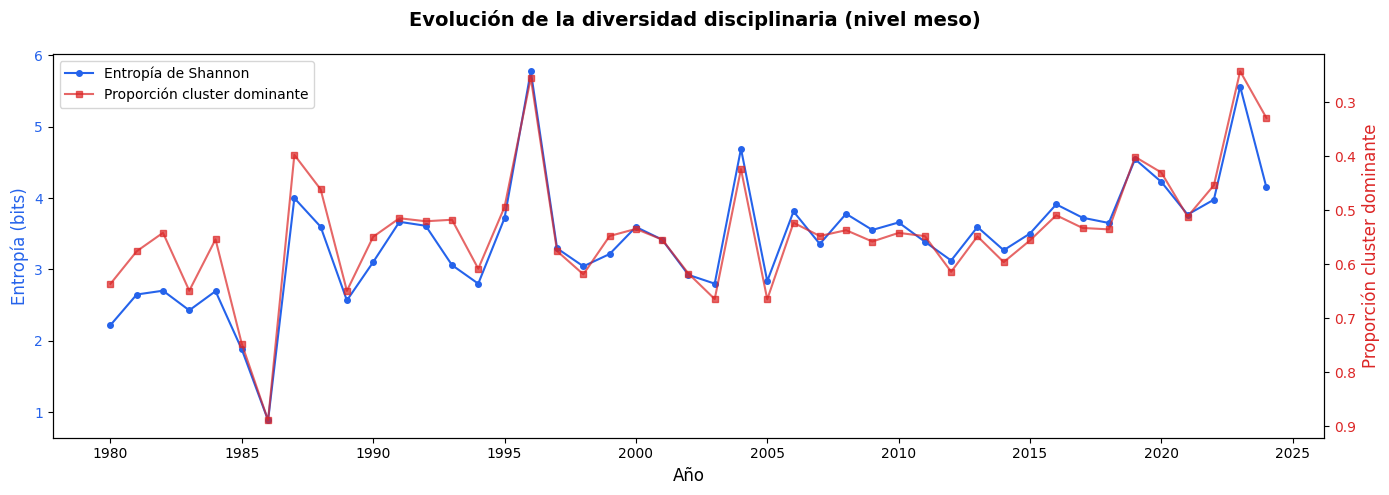

In [45]:

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax1 = plt.subplots(figsize=(14, 5))

# Entropía (eje izquierdo)
color_ent = "#2563eb"
ax1.plot(df_mod["year"], df_mod["entropia"], "-o", color=color_ent, 
         markersize=4, linewidth=1.5, label="Entropía de Shannon")
ax1.set_xlabel("Año", fontsize=12)
ax1.set_ylabel("Entropía (bits)", color=color_ent, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_ent)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(5))

# Proporción del cluster dominante (eje derecho, invertido)
ax2 = ax1.twinx()
color_dom = "#dc2626"
ax2.plot(df_mod["year"], df_mod["cluster_dom_prop"], "-s", color=color_dom,
         markersize=4, linewidth=1.5, alpha=0.7, label="Proporción cluster dominante")
ax2.set_ylabel("Proporción cluster dominante", color=color_dom, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_dom)
ax2.invert_yaxis()  # invertir para que "menos concentrado" suba

# Título y leyenda
fig.suptitle("Evolución de la diversidad disciplinaria (nivel meso)", fontsize=14, fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

plt.tight_layout()
plt.savefig("Output/diversidad_temporal_meso.png", dpi=150, bbox_inches="tight")
plt.show()


In [46]:
import src.stats.config as cfg
import src.global_config as gcfg
from src.stats import analysis as stat_analysis
from src.stats import data_loader as stat_loader

taxonomy_map = stat_loader.load_taxonomy_mapping(cfg.TAXONOMY_CSV)
snapshots, df_index, df_issues = stat_loader.build_yearly_index(
    gcfg.DATA_FOLDER, gcfg.START_YEAR, gcfg.END_YEAR,
    taxonomy_map, cfg.LEVEL
)


Nivel taxonómico:  meso
[OK] 1980 | alters=26 | cats_unique=19 | missing_csv=0
[OK] 1981 | alters=63 | cats_unique=39 | missing_csv=0
[OK] 1982 | alters=58 | cats_unique=34 | missing_csv=0
[OK] 1983 | alters=35 | cats_unique=27 | missing_csv=0
[OK] 1984 | alters=45 | cats_unique=28 | missing_csv=0
[OK] 1985 | alters=33 | cats_unique=25 | missing_csv=0
[OK] 1986 | alters=18 | cats_unique=14 | missing_csv=0
[OK] 1987 | alters=286 | cats_unique=127 | missing_csv=0
[OK] 1988 | alters=128 | cats_unique=67 | missing_csv=0
[OK] 1989 | alters=61 | cats_unique=35 | missing_csv=0
[OK] 1990 | alters=85 | cats_unique=48 | missing_csv=1
[OK] 1991 | alters=244 | cats_unique=107 | missing_csv=0
[OK] 1992 | alters=224 | cats_unique=114 | missing_csv=0
[OK] 1993 | alters=103 | cats_unique=55 | missing_csv=0
[OK] 1994 | alters=63 | cats_unique=41 | missing_csv=0
[OK] 1995 | alters=167 | cats_unique=91 | missing_csv=0
[OK] 1996 | alters=595 | cats_unique=210 | missing_csv=0
[OK] 1997 | alters=150 | cats_

In [47]:

# 1. Obtener la modularidad temporal
df_mod = stat_analysis.resumen_modularidad_temporal(snapshots)

# 2. Cargar PC1 de GraphSAGE
df_all = stat_analysis.cargar_y_unir_datos(cfg.LEVEL)
pc1_sage = df_all["sage_pc1"].values     # ← nombre claro
pc1_years = df_all["year"].values




#Entropia de shannon para cada año a partir de la ontologia a nivel mesotopico.
#Se calculó la correlación entre la entropia y el vlaor de pca1 arrojado por graphsage

#"¿El embedding de GraphSAGE se parece a la diversidad disciplinaria?" ones + hierarchical
df_corr = stat_analysis.correlacionar_modularidad(
    df_mod, 
    pc1_series=pc1_sage,
    pc1_years=pc1_years,
    pc1_label="PC1_graphsage"
)



  CORRELACIÓN: Modularidad vs PC1_graphsage
  Años alineados: 45
-----------------------------------------------------------------
  entropia            :  ρ = -0.5888  (p = 0.0000)  R² = 0.3466  ***
  hhi                 :  ρ = +0.4315  (p = 0.0031)  R² = 0.1862  **
  n_clusters          :  ρ = -0.6354  (p = 0.0000)  R² = 0.4037  ***
  cluster_dom_prop    :  ρ = +0.3774  (p = 0.0106)  R² = 0.1424  *
  n_alters            :  ρ = -0.5275  (p = 0.0002)  R² = 0.2783  ***
  D0                  :  ρ = -0.6354  (p = 0.0000)  R² = 0.4037  ***
  D1                  :  ρ = -0.3914  (p = 0.0079)  R² = 0.1532  **
  D2                  :  ρ = -0.2795  (p = 0.0630)  R² = 0.0781  ns
-----------------------------------------------------------------
  → 🟡 CORRELACIÓN MODERADA (|ρ| = 0.59): Comparten información
    parcial. La ontología aporta info complementaria → LUZ VERDE para Eje 2.


In [48]:
from src.baselines.e1_pca_promedios import pca_sobre_promedios
from src.gnn.analysis import obtener_promedios_anuales

nombres_features = [key for _, key in gcfg.FEATURES]
df_features = obtener_promedios_anuales(
    list(range(gcfg.START_YEAR, gcfg.END_YEAR + 1)),
    nombres_features,
    gcfg.DATA_FOLDER
)

df_pc1_raw, info_e1 = pca_sobre_promedios(df_features)

#Entropia de shannon para cada año a partir de la ontologia a nivel mesotopico.
#Se calculó la correlación entre la entropia y el vlaor de pca1 arrojado por unicamente calculos estadísticos

#El embedding estadístico se parece a la entropia?
df_corr_raw = stat_analysis.correlacionar_modularidad(
    df_mod,
    pc1_series=df_pc1_raw["PC1_raw"].values,
    pc1_years=df_pc1_raw["year"].values,
    pc1_label="PC1_raw"
)


Calculando promedios anuales de los datos crudos (sin ego)...
[E1] Se invirtió PC1_raw para alinearlo con 'Percent of documents'. Corr original: -0.4414
  CORRELACIÓN: Modularidad vs PC1_raw
  Años alineados: 45
-----------------------------------------------------------------
  entropia            :  ρ = -0.5471  (p = 0.0001)  R² = 0.2993  ***
  hhi                 :  ρ = +0.4557  (p = 0.0017)  R² = 0.2076  **
  n_clusters          :  ρ = -0.3675  (p = 0.0130)  R² = 0.1351  *
  cluster_dom_prop    :  ρ = +0.4492  (p = 0.0020)  R² = 0.2018  **
  n_alters            :  ρ = -0.2639  (p = 0.0798)  R² = 0.0697  ns
  D0                  :  ρ = -0.3675  (p = 0.0130)  R² = 0.1351  *
  D1                  :  ρ = -0.4184  (p = 0.0042)  R² = 0.1750  **
  D2                  :  ρ = -0.3931  (p = 0.0076)  R² = 0.1545  **
-----------------------------------------------------------------
  → 🟡 CORRELACIÓN MODERADA (|ρ| = 0.55): Comparten información
    parcial. La ontología aporta info complementar

In [71]:
#esto de manera temporal, se suopne que ya lo corri en un notebook anterior
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
historia, auc_mean = pipeline.run_temporal_graphsage(device)


Feature mode: biblio_and_ontology (in_channels=2457)
Ontology feature level: micro
Warm-start: True
Pooling mode: hierarchical
Modo: con memoria
Epoch 001 | Loss: 0.6946
Epoch 020 | Loss: 0.4616
Epoch 040 | Loss: 0.4059
Epoch 060 | Loss: 0.4448
1980 procesado. (alters=26, total_nodos=27, pooling=hierarchical, AUC=0.0000)
Epoch 001 | Loss: 0.7693
Epoch 020 | Loss: 0.4204
Epoch 040 | Loss: 0.4727
Epoch 060 | Loss: 0.3778
1981 procesado. (alters=63, total_nodos=64, pooling=hierarchical, AUC=0.0833)
Epoch 001 | Loss: 0.8093
Epoch 020 | Loss: 0.4544
Epoch 040 | Loss: 0.4313
Epoch 060 | Loss: 0.3748
1982 procesado. (alters=58, total_nodos=59, pooling=hierarchical, AUC=0.2727)
Epoch 001 | Loss: 0.4937
Epoch 020 | Loss: 0.4114
Epoch 040 | Loss: 0.3902
Epoch 060 | Loss: 0.4359
1983 procesado. (alters=35, total_nodos=36, pooling=hierarchical, AUC=0.2857)
Epoch 001 | Loss: 0.3925
Epoch 020 | Loss: 0.3716
Epoch 040 | Loss: 0.4493
Epoch 060 | Loss: 0.3793
1984 procesado. (alters=45, total_nodos=46,

In [72]:



from src.gnn import ablation
ablation.log_run(auc_mean=auc_mean, rho_entropia=0.38, rho_pc1_raw=0.21)


[Ablation] Corrida 1 guardada en: ./Output/ablation/SOM_biblio-and-ontology-micro_hierarchical-meso.csv
           AUC=0.8403, ρ_entropia=0.38, ρ_pc1_raw=0.21


'./Output/ablation/SOM_biblio-and-ontology-micro_hierarchical-meso.csv'